In [15]:
import os, sys, glob, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.stats import ttest_ind

REPO = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
import eigen_steering
from eigen_steering import EigenMap, MPRAHead, AlphaGenomeMPRA

eigen_steering.WEIGHTS_PATH = os.path.join(REPO, 'pytorch_base_model', 'model_fold_0.safetensors')
CKPT_DIR = os.path.join(REPO, 'models')

CT = {'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
df = df.dropna(subset=['sequence'] + [f'{ct}_log2FC' for ct in CT]).reset_index(drop=True)

em = EigenMap(model_names=CT, device=DEVICE)
em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in CT})

raw = np.load(os.path.join(REPO, 'genomic_targets', 'data', 'deeplift_attributions.npz'))
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna(); n = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{ct}_log2FC' for ct in CT]].notna().all(axis=1).values
del df_full

ohe = em.X.numpy()
for ct in CT:
    hyp = raw[f'attr_{ct}'][:n][keep]
    em.attr_hyp[ct] = hyp; em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][:n][keep]

# Load models on GPU (ckpts at models/{name}/best_stage2.pt)
def _load_model_patched(self, ct, squeeze=False):
    eigen_steering._load_heavy_deps()
    name = self.model_names[ct]
    ckpt_path = os.path.join(CKPT_DIR, name, 'best_stage2.pt')
    print(f"  Loading {ct}: {ckpt_path}")
    enc = eigen_steering.AlphaGenome.from_pretrained(eigen_steering.WEIGHTS_PATH, device='cpu')
    eigen_steering.remove_all_heads(enc)
    hd = MPRAHead()
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    enc.load_state_dict(ckpt['model_state_dict'], strict=False)
    hd.load_state_dict(ckpt['head_state_dict'])
    return AlphaGenomeMPRA(enc, hd, squeeze=squeeze).to(self.device).eval()

EigenMap._load_model = _load_model_patched
models = em._load_models()

print(f'\n{len(df)} seqs on {DEVICE}')
for ct, m in models.items():
    print(f'  {ct}: {sum(p.numel() for p in m.parameters())/1e6:.2f}M params on {next(m.parameters()).device}')

device: cuda
EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
Loaded 56975 sequences, X shape: torch.Size([56975, 4, 281])
  Loading K562: /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/K562_v6_do075/best_stage2.pt
  Loading HepG2: /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/HepG2_v6_do03/best_stage2.pt

56975 seqs on cuda
  K562: 408.64M params on cuda:0
  HepG2: 408.64M params on cuda:0


In [16]:
# EI lib (focus_idx) from selected hippo target library
with open(os.path.join(REPO, 'virtual_perturbations/libraries/hippo_target_library.pkl'), 'rb') as f:
    target_lib = pickle.load(f)
focus_idx = target_lib['df']['seq_idx'].values

# Per-replicate MPRA stats -> diffs (HepG2 - K562) + Welch p
MPRA_DIR = os.path.join(REPO, 'data', 'full_joint_mpra')
COLS = ['cell', 'rep', 'name', 'dna', 'rna', 'ratio', 'log2_ratio', 'n_bc']
def _load(cell):
    return pd.concat([pd.read_csv(f, sep='\t', header=None, names=COLS)
                      for f in sorted(glob.glob(f'{MPRA_DIR}/{cell}/{cell}_rep*.tsv'))],
                     ignore_index=True)
hep_w = _load('HepG2').pivot_table(index='name', columns='rep', values='log2_ratio')
k_w   = _load('K562' ).pivot_table(index='name', columns='rep', values='log2_ratio')
shared = hep_w.index.intersection(k_w.index)
H, K = hep_w.loc[shared].values, k_w.loc[shared].values
ok = np.isfinite(H).all(1) & np.isfinite(K).all(1)
_, pv = ttest_ind(H[ok], K[ok], axis=1, equal_var=False)
diffs = df['name'].map(dict(zip(shared[ok], H[ok].mean(1) - K[ok].mean(1)))).values.astype(float)
pvals = df['name'].map(dict(zip(shared[ok], pv))).values.astype(float)

# p-val lib (bioinfo_idx): p<0.05 & |log2FC|>2
P_THRESH, LFC_THRESH = 0.05, 2.0
finite = np.isfinite(diffs) & np.isfinite(pvals)
bioinfo_idx = np.where(finite & (pvals < P_THRESH) & (np.abs(diffs) > LFC_THRESH))[0]

# cos-sim (importance, z-scored)
cossim = em.cosine_similarity(mode='importance', zscore=True)

print(f'EI lib: {len(focus_idx)} | p-val lib: {len(bioinfo_idx)} | cossim: {cossim.shape} | diffs: {diffs.shape}')

EI lib: 1059 | p-val lib: 956 | cossim: (56975,) | diffs: (56975,)


In [17]:
# Backfill the 1004 blank-category synthetic rows
mask_blank = df['category'].fillna('').eq('')
df.loc[mask_blank & df['name'].str.startswith('controlhigh'), 'category'] = 'synthetic_high'
df.loc[mask_blank & df['name'].str.startswith('C:SLEA'),      'category'] = 'synthetic_syntax'
print(df['category'].value_counts(dropna=False))

category
putative enhancer, HepG2    17900
putative enhancer, WTC11    17707
putative enhancer, K562     17554
promoter                     2193
NaN                           963
negative, shuffled            286
negative HepG2, Smith         153
positive HepG2, Smith         133
positive K562, Kellis          48
synthetic_syntax               37
synthetic_high                  1
Name: count, dtype: int64


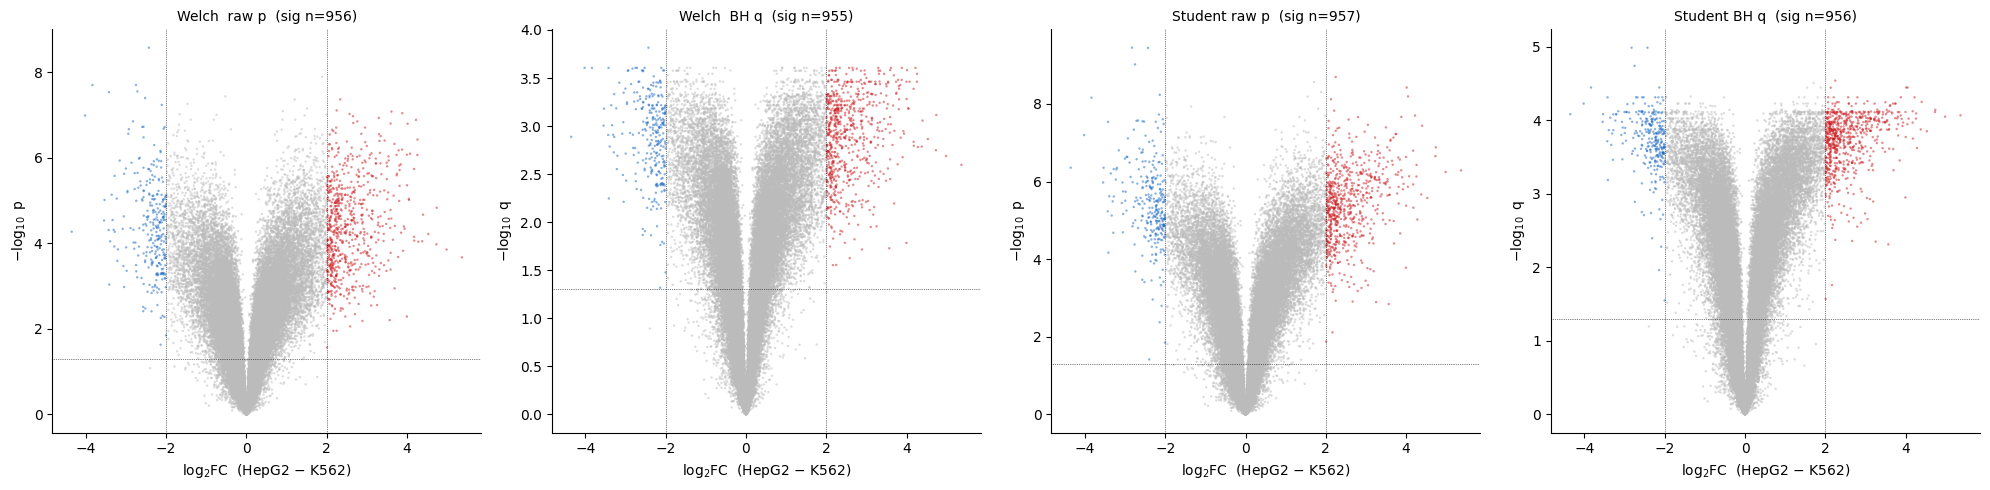

Welch    raw p<0.05 & |log2FC|>2.0: 956
Welch    BH  q<0.05 & |log2FC|>2.0: 955
Student  raw p<0.05 & |log2FC|>2.0: 957
Student  BH  q<0.05 & |log2FC|>2.0: 956


In [18]:
# BH-corrected p-values: Welch (unequal var) + Student's t (equal var).
# Same per-rep log2_ratio matrix as before. Manual BH (no statsmodels needed).

_, pv_welch   = ttest_ind(H[ok], K[ok], axis=1, equal_var=False)
_, pv_student = ttest_ind(H[ok], K[ok], axis=1, equal_var=True)

def _to_full(pv_short):
    return df['name'].map(dict(zip(shared[ok], pv_short))).values.astype(float)

p_welch   = _to_full(pv_welch)
p_student = _to_full(pv_student)

def _bh(p):
    out = np.full_like(p, np.nan)
    m = np.isfinite(p)
    pv = p[m]; n = pv.size
    order = np.argsort(pv)
    ranked = pv[order] * n / (np.arange(n) + 1)
    q = np.clip(np.minimum.accumulate(ranked[::-1])[::-1], 0, 1)
    bh = np.empty(n); bh[order] = q
    out[m] = bh
    return out

padj_welch   = _bh(p_welch)
padj_student = _bh(p_student)

PADJ, LFC = 0.05, 2.0
fin_d = np.isfinite(diffs)
bioinfo_idx_welch   = np.where(fin_d & (padj_welch   < PADJ) & (np.abs(diffs) > LFC))[0]
bioinfo_idx_student = np.where(fin_d & (padj_student < PADJ) & (np.abs(diffs) > LFC))[0]

# Volcano plots: x = log2FC (HepG2 - K562, +ve = HepG2 up), y = -log10(p or q)
panels = [
    ('Welch  raw p',     p_welch,      0.05),
    ('Welch  BH q',      padj_welch,   PADJ),
    ('Student raw p',    p_student,    0.05),
    ('Student BH q',     padj_student, PADJ),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=False)
for ax, (label, pv, thr) in zip(axes, panels):
    fin = np.isfinite(diffs) & np.isfinite(pv)
    nlp = -np.log10(np.clip(pv, 1e-300, 1.0))
    sig = fin & (pv < thr) & (np.abs(diffs) > LFC)
    colors = np.where(sig & (diffs > 0), '#cb181d',
              np.where(sig & (diffs < 0), '#1565C0', '#bbbbbb'))
    ax.scatter(diffs[fin], nlp[fin], s=3, c=colors[fin],
               alpha=0.5, edgecolors='none', rasterized=True)
    ax.axvline( LFC, color='k', lw=0.5, ls=':')
    ax.axvline(-LFC, color='k', lw=0.5, ls=':')
    ax.axhline(-np.log10(thr), color='k', lw=0.5, ls=':')
    ax.set_xlabel('log$_2$FC  (HepG2 $-$ K562)', fontsize=10)
    ax.set_ylabel(f'$-\\log_{{10}}$ {label.split()[-1]}', fontsize=10)
    ax.set_title(f'{label}  (sig n={sig.sum()})', fontsize=10)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

print(f'Welch    raw p<0.05 & |log2FC|>{LFC}: {(np.isfinite(p_welch)   & (p_welch   < 0.05) & (np.abs(diffs) > LFC)).sum()}')
print(f'Welch    BH  q<0.05 & |log2FC|>{LFC}: {len(bioinfo_idx_welch)}')
print(f'Student  raw p<0.05 & |log2FC|>{LFC}: {(np.isfinite(p_student) & (p_student < 0.05) & (np.abs(diffs) > LFC)).sum()}')
print(f'Student  BH  q<0.05 & |log2FC|>{LFC}: {len(bioinfo_idx_student)}')

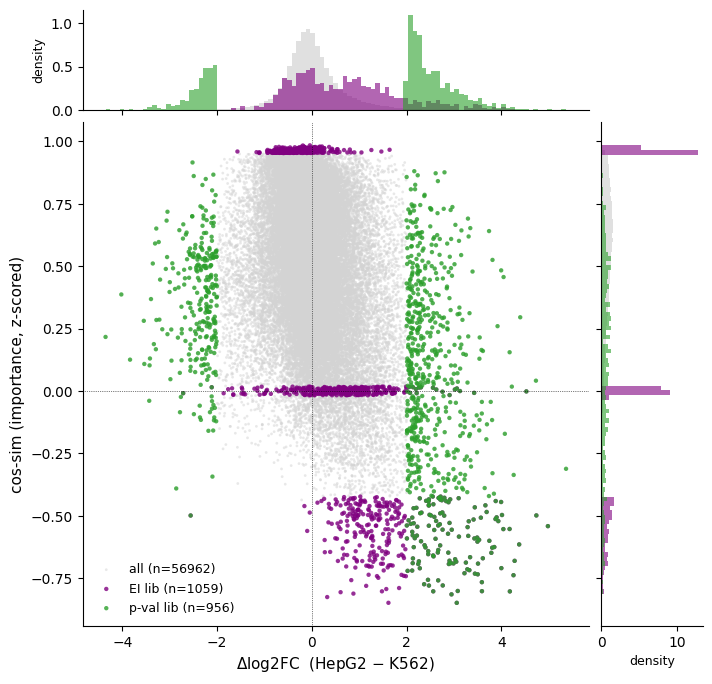

In [19]:
# cos-sim vs delta log2FC: all seqs gray, EI lib purple, p-val lib green.
# Marginal histograms on each axis.
fin = np.isfinite(cossim) & np.isfinite(diffs)

fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[5, 1], height_ratios=[1, 5],
                      wspace=0.04, hspace=0.04)
ax = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax)

ax.scatter(diffs[fin], cossim[fin], s=4, c='lightgray',
           alpha=0.5, edgecolors='none', label=f'all (n={fin.sum()})', rasterized=True)
ax.scatter(diffs[focus_idx], cossim[focus_idx], s=10, c='purple',
           alpha=0.8, edgecolors='none', label=f'EI lib (n={len(focus_idx)})')
ax.scatter(diffs[bioinfo_idx], cossim[bioinfo_idx], s=10, c='#2ca02c',
           alpha=0.8, edgecolors='none', label=f'p-val lib (n={len(bioinfo_idx)})')
ax.axhline(0, color='k', lw=0.5, ls=':')
ax.axvline(0, color='k', lw=0.5, ls=':')
ax.set_xlabel('$\\Delta$log2FC  (HepG2 $-$ K562)', fontsize=11)
ax.set_ylabel('cos-sim (importance, z-scored)', fontsize=11)
ax.legend(fontsize=9, frameon=False, loc='lower left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

xbins = np.linspace(np.nanmin(diffs[fin]), np.nanmax(diffs[fin]), 100)
ax_top.hist(diffs[fin],         bins=xbins, color='lightgray', alpha=0.7, density=True)
ax_top.hist(diffs[focus_idx],   bins=xbins, color='purple',    alpha=0.6, density=True)
ax_top.hist(diffs[bioinfo_idx], bins=xbins, color='#2ca02c',   alpha=0.6, density=True)
ax_top.tick_params(axis='x', labelbottom=False)
ax_top.set_ylabel('density', fontsize=9)
for sp in ('top', 'right'): ax_top.spines[sp].set_visible(False)

ybins = np.linspace(np.nanmin(cossim[fin]), np.nanmax(cossim[fin]), 100)
ax_right.hist(cossim[fin],         bins=ybins, color='lightgray', alpha=0.7,
              density=True, orientation='horizontal')
ax_right.hist(cossim[focus_idx],   bins=ybins, color='purple',    alpha=0.6,
              density=True, orientation='horizontal')
ax_right.hist(cossim[bioinfo_idx], bins=ybins, color='#2ca02c',   alpha=0.6,
              density=True, orientation='horizontal')
ax_right.tick_params(axis='y', labelleft=False)
ax_right.set_xlabel('density', fontsize=9)
for sp in ('top', 'right'): ax_right.spines[sp].set_visible(False)

plt.show()

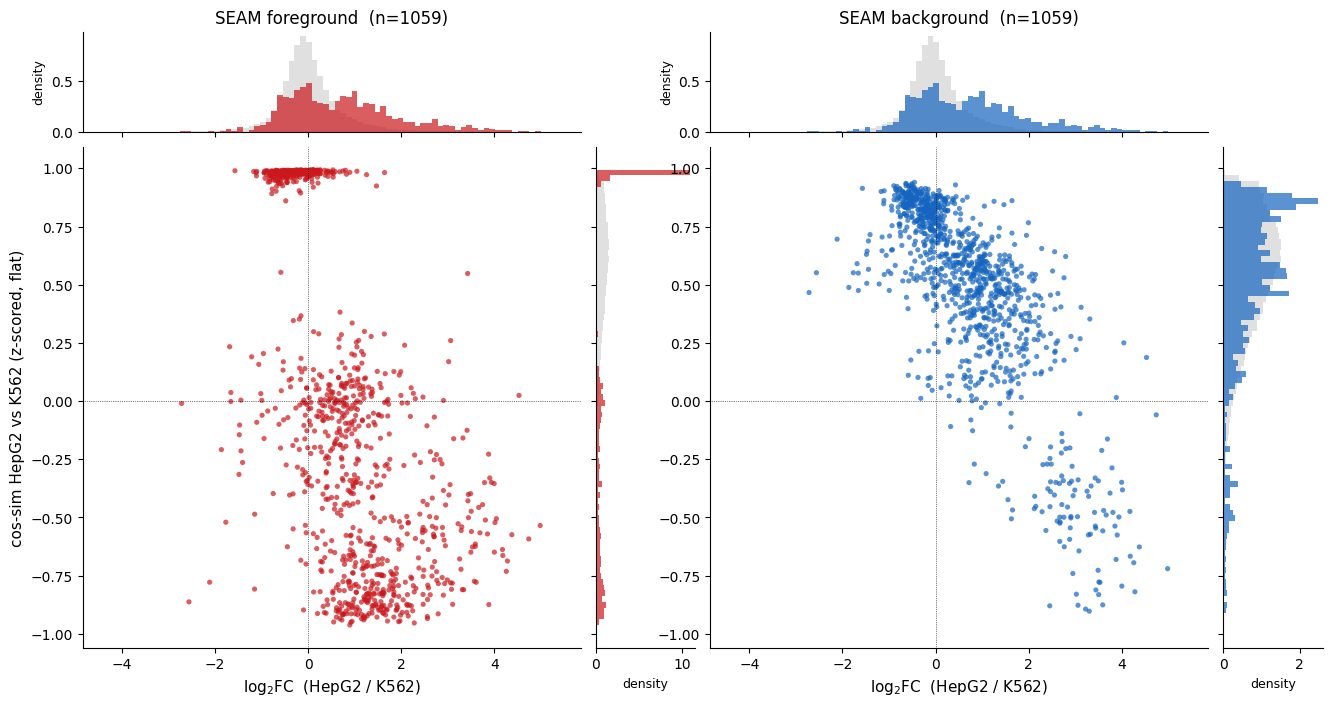

In [29]:
# Mech-vs-func space, 1059 lib seqs. Y = per-seq HepG2 vs K562 cos-sim (z-scored, flat).
#   left  = SEAM foreground (cell-type-specific signal)
#   right = SEAM average_background (shuffle baseline)
# X = log2FC(HepG2/K562) from df. Gray distribution = all 56K seqs (overlaid on marginals only).
FG_DIR = os.path.join(REPO, 'SEAM_target_spaces', 'results', 'foregrounds')
lib_df = target_lib['df']
lib_idx = lib_df['seq_idx'].values

def _zflat(a):
    a = a.astype(np.float64).ravel()
    s = a.std()
    return (a - a.mean()) / s if s > 0 else a - a.mean()

def _cos(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(a @ b / (na * nb)) if na > 0 and nb > 0 else np.nan

cos_fg = np.full(len(lib_idx), np.nan)
cos_bg = np.full(len(lib_idx), np.nan)
for i, sid in enumerate(lib_idx):
    try:
        fH = _zflat(np.load(f'{FG_DIR}/HepG2/{sid}/foreground_scaled.npy'))
        fK = _zflat(np.load(f'{FG_DIR}/K562/{sid}/foreground_scaled.npy'))
        bH = _zflat(np.load(f'{FG_DIR}/HepG2/{sid}/average_background_scaled.npy'))
        bK = _zflat(np.load(f'{FG_DIR}/K562/{sid}/average_background_scaled.npy'))
        cos_fg[i] = _cos(fH, fK)
        cos_bg[i] = _cos(bH, bK)
    except FileNotFoundError:
        pass
print(f'FG cossim: {np.isfinite(cos_fg).sum()}/{len(lib_idx)} | BG cossim: {np.isfinite(cos_bg).sum()}/{len(lib_idx)}')

# X-axis: log2 fold change between HepG2 and K562
lfc = (df['HepG2_log2FC'] - df['K562_log2FC']).values
x_lib = lfc[lib_idx]

fin_all = np.isfinite(lfc) & np.isfinite(cossim)
yall = np.concatenate([
    cossim[fin_all],
    cos_fg[np.isfinite(cos_fg)],
    cos_bg[np.isfinite(cos_bg)],
])
xall = np.concatenate([lfc[fin_all], x_lib[np.isfinite(x_lib)]])
xb = np.linspace(xall.min(), xall.max(), 80)
yb = np.linspace(yall.min(), yall.max(), 80)

fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 4,
                      width_ratios=[5, 1, 5, 1],
                      height_ratios=[1, 5],
                      wspace=0.05, hspace=0.05)

panels = [
    (0, cos_fg, '#cb181d', 'SEAM foreground'),
    (2, cos_bg, '#1565C0', 'SEAM background'),
]
ax_main_first = None
for col, y, color, title in panels:
    ax = fig.add_subplot(gs[1, col])
    ax_top = fig.add_subplot(gs[0, col], sharex=ax)
    ax_right = fig.add_subplot(gs[1, col + 1], sharey=ax)
    if ax_main_first is None:
        ax_main_first = ax
    else:
        ax.sharey(ax_main_first)

    m = np.isfinite(x_lib) & np.isfinite(y)
    ax.scatter(x_lib[m], y[m], s=14, c=color, alpha=0.7, edgecolors='none')
    ax.axhline(0, color='k', lw=0.5, ls=':')
    ax.axvline(0, color='k', lw=0.5, ls=':')
    ax.set_xlabel('log$_2$FC  (HepG2 / K562)', fontsize=11)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if col == 0:
        ax.set_ylabel('cos-sim HepG2 vs K562 (z-scored, flat)', fontsize=11)

    # Top marginal: gray = all 56K, color = lib
    ax_top.hist(lfc[fin_all], bins=xb, color='lightgray', alpha=0.7, density=True,
                label=f'all (n={fin_all.sum()})')
    ax_top.hist(x_lib[m],     bins=xb, color=color,       alpha=0.7, density=True,
                label=f'lib (n={m.sum()})')
    ax_top.tick_params(axis='x', labelbottom=False)
    ax_top.set_ylabel('density', fontsize=9)
    ax_top.set_title(f'{title}  (n={m.sum()})', fontsize=12)
    for sp in ('top', 'right'): ax_top.spines[sp].set_visible(False)

    # Right marginal: gray = all 56K cossim (full DeepLIFT), color = SEAM lib
    ax_right.hist(cossim[fin_all], bins=yb, color='lightgray', alpha=0.7,
                  density=True, orientation='horizontal')
    ax_right.hist(y[m],            bins=yb, color=color,       alpha=0.7,
                  density=True, orientation='horizontal')
    ax_right.tick_params(axis='y', labelleft=False)
    ax_right.set_xlabel('density', fontsize=9)
    for sp in ('top', 'right'): ax_right.spines[sp].set_visible(False)

plt.show()

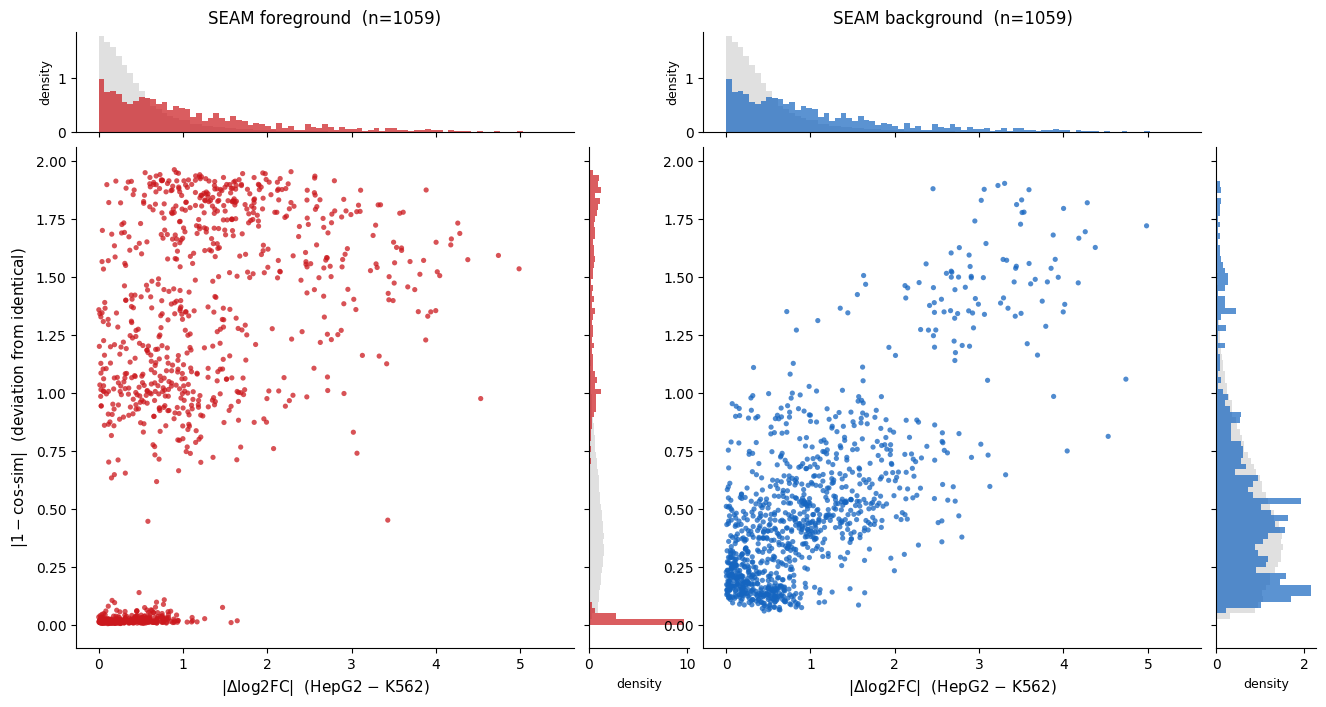

In [31]:
# Same FG/BG plot, but: x = |Δlog2FC|, y = |1 - cossim| (deviation from identical, 0..2).
adiffs = np.abs(lfc)
adiffs_lib = adiffs[lib_idx]
dev_fg = np.abs(1.0 - cos_fg)
dev_bg = np.abs(1.0 - cos_bg)
dev_all = np.abs(1.0 - cossim)  # full DeepLIFT, all 56K (gray reference)

fin_all = np.isfinite(adiffs) & np.isfinite(dev_all)
xb = np.linspace(0, np.nanmax(adiffs[fin_all]), 80)
yall = np.concatenate([
    dev_all[fin_all],
    dev_fg[np.isfinite(dev_fg)],
    dev_bg[np.isfinite(dev_bg)],
])
yb = np.linspace(0, yall.max(), 80)

fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 4,
                      width_ratios=[5, 1, 5, 1],
                      height_ratios=[1, 5],
                      wspace=0.05, hspace=0.05)

panels = [
    (0, dev_fg, '#cb181d', 'SEAM foreground'),
    (2, dev_bg, '#1565C0', 'SEAM background'),
]
ax_main_first = None
for col, y, color, title in panels:
    ax = fig.add_subplot(gs[1, col])
    ax_top = fig.add_subplot(gs[0, col], sharex=ax)
    ax_right = fig.add_subplot(gs[1, col + 1], sharey=ax)
    if ax_main_first is None:
        ax_main_first = ax
    else:
        ax.sharey(ax_main_first)

    m = np.isfinite(adiffs_lib) & np.isfinite(y)
    ax.scatter(adiffs_lib[m], y[m], s=14, c=color, alpha=0.75, edgecolors='none')
    ax.set_xlabel('$|\\Delta$log2FC$|$  (HepG2 $-$ K562)', fontsize=11)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if col == 0:
        ax.set_ylabel('$|1 - $cos-sim$|$  (deviation from identical)', fontsize=11)

    ax_top.hist(adiffs[fin_all], bins=xb, color='lightgray', alpha=0.7, density=True,
                label=f'all (n={fin_all.sum()})')
    ax_top.hist(adiffs_lib[m],   bins=xb, color=color,       alpha=0.7, density=True,
                label=f'lib (n={m.sum()})')
    ax_top.tick_params(axis='x', labelbottom=False)
    ax_top.set_ylabel('density', fontsize=9)
    ax_top.set_title(f'{title}  (n={m.sum()})', fontsize=12)
    for sp in ('top', 'right'): ax_top.spines[sp].set_visible(False)

    ax_right.hist(dev_all[fin_all], bins=yb, color='lightgray', alpha=0.7,
                  density=True, orientation='horizontal')
    ax_right.hist(y[m],             bins=yb, color=color,       alpha=0.7,
                  density=True, orientation='horizontal')
    ax_right.tick_params(axis='y', labelleft=False)
    ax_right.set_xlabel('density', fontsize=9)
    for sp in ('top', 'right'): ax_right.spines[sp].set_visible(False)

plt.show()

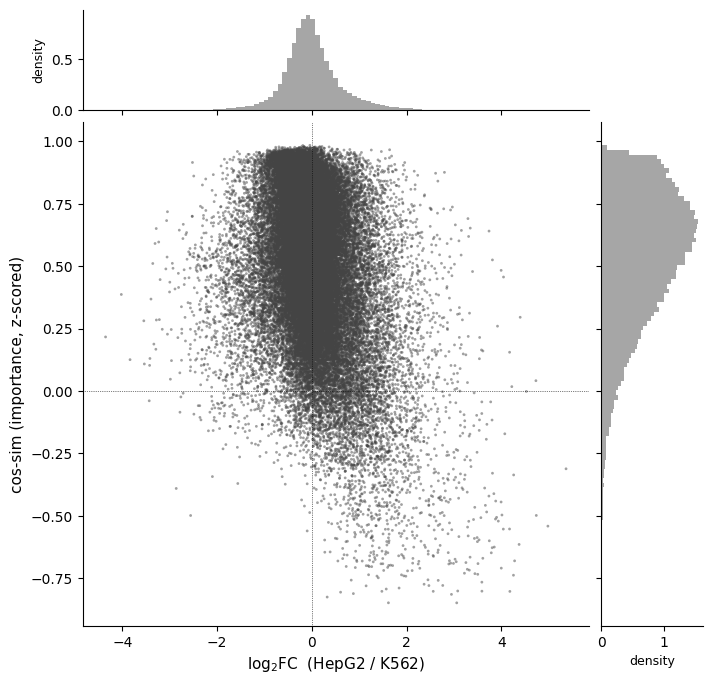

In [21]:
# Same scatter, single color. x = log2FC HepG2/K562 (precomputed in df).
lfc = (df['HepG2_log2FC'] - df['K562_log2FC']).values
fin = np.isfinite(cossim) & np.isfinite(lfc)

fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[5, 1], height_ratios=[1, 5],
                      wspace=0.04, hspace=0.04)
ax = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax)

ax.scatter(lfc[fin], cossim[fin], s=4, c='#444444',
           alpha=0.5, edgecolors='none', rasterized=True)
ax.axhline(0, color='k', lw=0.5, ls=':')
ax.axvline(0, color='k', lw=0.5, ls=':')
ax.set_xlabel('log$_2$FC  (HepG2 / K562)', fontsize=11)
ax.set_ylabel('cos-sim (importance, z-scored)', fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

xbins = np.linspace(np.nanmin(lfc[fin]), np.nanmax(lfc[fin]), 100)
ax_top.hist(lfc[fin], bins=xbins, color='gray', alpha=0.7, density=True)
ax_top.tick_params(axis='x', labelbottom=False)
ax_top.set_ylabel('density', fontsize=9)
for sp in ('top', 'right'): ax_top.spines[sp].set_visible(False)

ybins = np.linspace(np.nanmin(cossim[fin]), np.nanmax(cossim[fin]), 100)
ax_right.hist(cossim[fin], bins=ybins, color='gray', alpha=0.7,
              density=True, orientation='horizontal')
ax_right.tick_params(axis='y', labelleft=False)
ax_right.set_xlabel('density', fontsize=9)
for sp in ('top', 'right'): ax_right.spines[sp].set_visible(False)

plt.show()

In [22]:
SHOW = [
    'putative enhancer, HepG2',
    'putative enhancer, WTC11',
    'putative enhancer, K562',
    'promoter',
    'negative, shuffled',
    'negative HepG2, Smith',
    'positive HepG2, Smith',
    'positive K562, Kellis',
    'synthetic_high',
    'synthetic_syntax',
]

In [23]:
# Raw category labels from the source CSV, untouched (no backfill).                                                                                                                                                                                                                                                                                                                                                       
df_raw = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
print(df_raw['category'].value_counts(dropna=False)) 

category
putative enhancer, HepG2    17900
putative enhancer, WTC11    17707
putative enhancer, K562     17554
promoter                     2193
NaN                          1004
negative, shuffled            286
negative HepG2, Smith         153
positive HepG2, Smith         135
positive K562, Kellis          48
Name: count, dtype: int64


In [24]:
                  
# Backfill the 1004 blank-category synthetic rows                                                                                                                                                                                                                                                                                                                                                                         
mask_blank = df['category'].fillna('').eq('')                                                                                                                                                                                                                                                                                                                                                                             
df.loc[mask_blank & df['name'].str.startswith('controlhigh'), 'category'] = 'synthetic_high'                                                                                                                                                                                                                                                                                                                              
df.loc[mask_blank & df['name'].str.startswith('C:SLEA'),      'category'] = 'synthetic_syntax'                                                                                                                                                                                                                                                                                                                            
                                                                                                                                                                                                                                                                                                                                                                                                                        
# Remaining blanks: name starts with a cell-line prefix like "WTC11_seq...", "K562_...", "HepG2_..."                                                                                                                                                                                                                                                                                                                      
mask_blank = df['category'].fillna('').eq('')                                                                                                                                                                                                                                                                                                                                                                             
prefix = df.loc[mask_blank, 'name'].str.extract(r'^([A-Za-z0-9]+)_', expand=False)                                                                                                                                                                                                                                                                                                                                        
df.loc[mask_blank, 'category'] = (prefix + '_unknowns').values                                                                                                                                                                                                                                                                                                                                                            
                                                                                                                                                                                                                                                                                                                                                                                                                        
print(df['category'].value_counts(dropna=False))

category
putative enhancer, HepG2    17900
putative enhancer, WTC11    17707
putative enhancer, K562     17554
promoter                     2193
K562_unknowns                 324
WTC11_unknowns                322
negative, shuffled            286
HepG2_unknowns                193
negative HepG2, Smith         153
positive HepG2, Smith         133
NaN                           118
positive K562, Kellis          48
synthetic_syntax               37
UWpeak21365_unknowns            1
UWpeak11643_unknowns            1
seq70704_unknowns               1
seq59122_unknowns               1
seq438_unknowns                 1
seq19485_unknowns               1
synthetic_high                  1
Name: count, dtype: int64


In [25]:
mask_blank = df['category'].fillna('').eq('')                                                                                                                                                                                                                                                                                                                                                                             
df.loc[mask_blank & df['name'].str.startswith('ENSG'), 'category'] = 'ensembl_gene'
print(df['category'].value_counts(dropna=False))                                                                                                                                                                                                                                                                                                                                                                          
                  

category
putative enhancer, HepG2    17900
putative enhancer, WTC11    17707
putative enhancer, K562     17554
promoter                     2193
K562_unknowns                 324
WTC11_unknowns                322
negative, shuffled            286
HepG2_unknowns                193
negative HepG2, Smith         153
positive HepG2, Smith         133
ensembl_gene                  118
positive K562, Kellis          48
synthetic_syntax               37
UWpeak21365_unknowns            1
UWpeak11643_unknowns            1
seq70704_unknowns               1
seq59122_unknowns               1
seq438_unknowns                 1
seq19485_unknowns               1
synthetic_high                  1
Name: count, dtype: int64


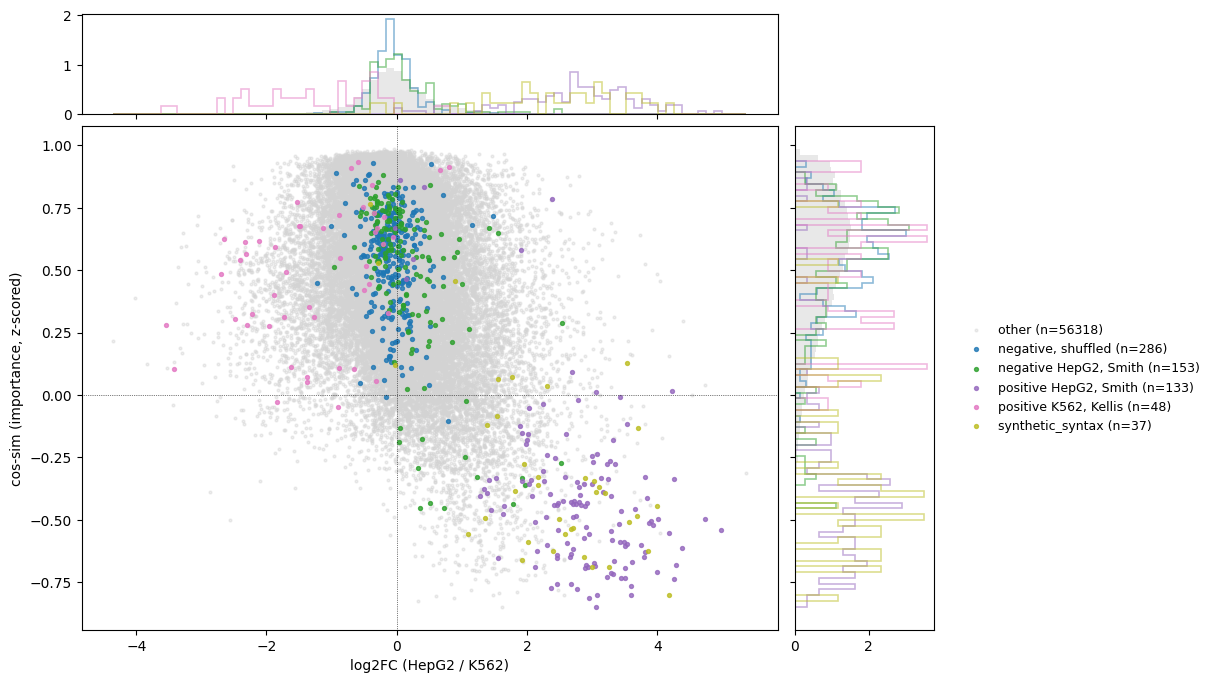

In [26]:
SHOW = [
    'negative, shuffled',
    'negative HepG2, Smith',
    'positive HepG2, Smith',
    'positive K562, Kellis',
    'synthetic_syntax',
    'ensemble_gene',

]

cat = df['category'].fillna('NA').values
lfc = (df['HepG2_log2FC'] - df['K562_log2FC']).values
fin = np.isfinite(cossim) & np.isfinite(lfc)

colors = plt.cm.tab10(np.linspace(0, 1, len(SHOW)))

fig = plt.figure(figsize=(11, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[5, 1], height_ratios=[1, 5], wspace=0.04, hspace=0.04)
ax = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax)

xb = np.linspace(np.nanmin(lfc[fin]), np.nanmax(lfc[fin]), 80)
yb = np.linspace(np.nanmin(cossim[fin]), np.nanmax(cossim[fin]), 80)

other = fin & ~np.isin(cat, SHOW)
ax.scatter(lfc[other], cossim[other], s=4, c='lightgray', alpha=0.4, label=f'other (n={other.sum()})')
ax_top.hist(lfc[other],  bins=xb, color='lightgray', density=True, alpha=0.5)
ax_right.hist(cossim[other], bins=yb, color='lightgray', density=True, alpha=0.5, orientation='horizontal')

for k, c in zip(SHOW, colors):
    m = fin & (cat == k)
    if not m.any(): continue
    ax.scatter(lfc[m], cossim[m], s=8, color=c, alpha=0.8, label=f'{k} (n={m.sum()})')
    ax_top.hist(lfc[m],  bins=xb, color=c, density=True, alpha=0.5, histtype='step', lw=1.2)
    ax_right.hist(cossim[m], bins=yb, color=c, density=True, alpha=0.5, histtype='step', lw=1.2, orientation='horizontal')

ax.axhline(0, color='k', lw=0.5, ls=':'); ax.axvline(0, color='k', lw=0.5, ls=':')
ax.set_xlabel('log2FC (HepG2 / K562)'); ax.set_ylabel('cos-sim (importance, z-scored)')
ax.legend(loc='center left', bbox_to_anchor=(1.25, 0.5), fontsize=9, frameon=False)
ax_top.tick_params(labelbottom=False); ax_right.tick_params(labelleft=False)
plt.show()